# Visual robustness check: predictions on strongly rotated/augmented images

`val`/`test` splits are evaluated on **plain, unaugmented** crops (deterministic
`build_eval_transform`, see `wings/dataset.py`) -- that's correct for tracking
comparable `val_mean_error_px` across epochs, but it never actually shows what
the model does on the kind of heavily rotated, noisy input it was trained to
handle (`TrainAugmentConfig`, see `jobs/online/README.md`). This notebook runs
inference on **test** images pushed through controlled rotation angles and
through the *actual* config 4 augmentation severity, and overlays predicted
(red x) vs. ground-truth (green o) landmarks so you can see it directly. Test
(not validation) is used deliberately here: validation is what training
selects/early-stops checkpoints against, so it's the set most likely to be
implicitly "tuned to" -- test is the untouched holdout.

Uses config 4's actual trained checkpoint (`models/online/last.ckpt`, copied
down from the HPC's
`wings/modeling/training/lightning-checkpoints/unet-400-online-augmentation-k5-4/`).
If you train a further config (e.g. "4b") and want to check that one instead,
update `CHECKPOINT_PATH` in the Setup cell below to point at its checkpoint.

## Setup

In [1]:
import random

import torch
import matplotlib.pyplot as plt
import numpy as np

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

from wings.config import PROCESSED_DATA_DIR, MODELS_DIR, COUNTRIES
from wings.dataset import WingsRawDataset, TransformedMaskDataset
from wings.transforms import TrainAugmentConfig, build_train_transform, build_eval_transform
from wings.visualizing.image_preprocess import mask_to_coords
from wings.modeling.unet import UNet
from wings.modeling.litnet import LitNet
from wings.modeling.loss import BCEDiceLoss

torch.manual_seed(0)

# --- Update these two to point at a different checkpoint (e.g. a future config 4b) ---
CHECKPOINT_PATH = MODELS_DIR / "online" / "last.ckpt"  # config 4's trained checkpoint, copied down from the HPC
MODEL_SIGMOID = False  # config 4 uses BCEDiceLoss -> UNet(sigmoid=False); flip to True for a config 1/3 checkpoint
# ---------------------------------------------------------------------------------------

OUTPUT_SIZE = 400
SQUARE_SIZE = 5

2026-09-25 11:22:21.376 | INFO     | wings.config:<module>:44 - PROJ_ROOT path is: C:\Users\X\projects\bees


2026-09-25 11:22:21.399 | INFO     | wings.config:<module>:68 - torch.cuda.get_device_name()='NVIDIA RTX A3000 12GB Laptop GPU'


W0925 11:22:24.319000 3532 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


## Load model + test split

Same raw source and the same `seed=42` split the real training run uses, so
`test_idx` here is exactly the held-out test set config 4 was never scored
against during training/early-stopping decisions.

In [2]:
mean_coords = torch.load(
    PROCESSED_DATA_DIR / "mask_datasets" / "rectangle" / "mean_shape.pth", weights_only=False
)

model = UNet(in_channels=1, out_channels=1, kernel_size=5, sigmoid=MODEL_SIGMOID)
lit_net = LitNet.load_from_checkpoint(
    CHECKPOINT_PATH,
    model=model,
    criterion=BCEDiceLoss(),  # unused for inference, LitNet just requires one
    num_epochs=1,
    mean_coords=mean_coords,
    strict=False,
)
lit_net.eval()
device = lit_net.device
print(f"Loaded checkpoint: {CHECKPOINT_PATH.name}")

raw = WingsRawDataset(COUNTRIES, PROCESSED_DATA_DIR / "cropped")
_, _, test_idx = raw.split(val_percentage=0.2, test_percentage=0.1, seed=42)
print(f"Test samples available: {len(test_idx)}")

Loaded checkpoint: last.ckpt


  0%|          | 0/21722 [00:00<?, ?it/s]

 74%|███████▍  | 16044/21722 [00:00<00:00, 80115.98it/s]

100%|██████████| 21722/21722 [00:00<00:00, 89990.63it/s]

Test samples available: 2172


## Helper functions

In [3]:
def predict_mask_coords(image_tensor):
    """image_tensor: (1, H, W), already normalized. Returns predicted
    landmark points in bottom-left convention (same as mask_to_coords/
    mean_coords everywhere else in this codebase)."""
    with torch.no_grad():
        output = lit_net.model(image_tensor.unsqueeze(0).to(device))
    probs = output if MODEL_SIGMOID else torch.sigmoid(output)
    pred_mask = (probs > 0.5).float().squeeze().cpu().numpy()
    return mask_to_coords(pred_mask)


def to_plot_xy(coords, img_size):
    """mask_to_coords returns bottom-left (x, y); flip y back for correct
    overlay on a top-left-origin imshow."""
    return [(x, img_size - y - 1) for x, y in coords]


def matched_distances(pred_coords, true_coords):
    """Direct nearest-neighbor (Hungarian) matching between predicted and
    ground-truth points in their shared pixel space.

    Deliberately NOT using litnet.py's handle_coordinates/recover_order here:
    that function's job is matching a prediction to the *mean_coords
    template* when there's no ground truth for this specific image to compare
    against directly (the real training/eval pipeline's dataset labels are
    already in a fixed order, so only the prediction needs reordering). Here
    pred_coords and true_coords are both already decoded from masks in the
    exact same transformed image -- there's no unknown relative orientation
    to solve for, so routing them through a Procrustes rotation-search is
    solving a harder problem than we have, and at large rotation angles it
    can converge to a wrong rotational assignment, silently inflating error
    (confirmed: a "catastrophic" ~150px handle_coordinates-based distance at
    90 deg turned out to be ~1-2px median error once matched directly).

    Matches min(len(pred), len(true)) pairs -- extra false-positive
    predictions are simply left unmatched rather than forcing a count match.
    Returns None only if either side is empty."""
    if len(pred_coords) == 0 or len(true_coords) == 0:
        return None
    pred = np.array(pred_coords)
    true = np.array(true_coords)
    cost = cdist(true, pred)
    row, col = linear_sum_assignment(cost)
    return torch.from_numpy(cost[row, col]).float()


def run_sample(base_index, transform):
    """Runs one raw test sample through `transform`, returning the
    transformed image + its ground-truth mask (built the identical way
    training builds it, via TransformedMaskDataset) plus decoded pred/true
    coordinates."""
    ds = TransformedMaskDataset(test_idx, transform, square_size=SQUARE_SIZE)
    image, target_mask, _, _ = ds[base_index]
    pred_coords = predict_mask_coords(image)
    true_coords = mask_to_coords(target_mask.squeeze(0).numpy())
    return image, pred_coords, true_coords


def overlay(ax, image, pred_coords, true_coords, title):
    img_size = image.shape[-1]
    ax.imshow(image.squeeze(0).numpy(), cmap="gray")
    if true_coords:
        tx, ty = zip(*to_plot_xy(true_coords, img_size))
        ax.scatter(tx, ty, s=160, facecolors="none", edgecolors="lime", linewidths=2.2, label="ground truth")
    if pred_coords:
        px, py = zip(*to_plot_xy(pred_coords, img_size))
        ax.scatter(px, py, c="red", s=90, marker="x", linewidths=2.2, label="predicted")
    ax.set_title(f"{title} (gt={len(true_coords)}, pred={len(pred_coords)})", fontsize=13)
    ax.legend(loc="upper right", fontsize=10)
    ax.axis("off")


def show_one(image, pred_coords, true_coords, title):
    """One large figure per image, shown immediately -- rendered one after
    another in the notebook rather than packed into a row."""
    fig, ax = plt.subplots(figsize=(9, 9))
    overlay(ax, image, pred_coords, true_coords, title)
    plt.tight_layout()
    plt.show()


# Config 4's actual training-time augmentation ("Aug B", jobs/online/README.md).
# Reused below by both the fixed random-draw grid and the re-runnable cell --
# each call to this transform draws fresh random parameters, it's not a
# one-time sample.
aug_b_cfg = TrainAugmentConfig(
    rotation_degrees=(-90.0, 90.0),
    triangle_noise_p=0.8,
    n_triangles_range=(40, 240),
    color_jitter_p=1.0,
    color_jitter_brightness_range=(0.5, 1.5),
    color_jitter_contrast_range=(0.5, 1.5),
)
aug_b_transform = build_train_transform(OUTPUT_SIZE, aug_b_cfg)

## Section A -- fixed rotation angle sweep

Pure rotation only (no noise/jitter), on a single test image, to isolate how
rotation alone affects predictions. Each angle is its own full-size figure,
shown one after another below.

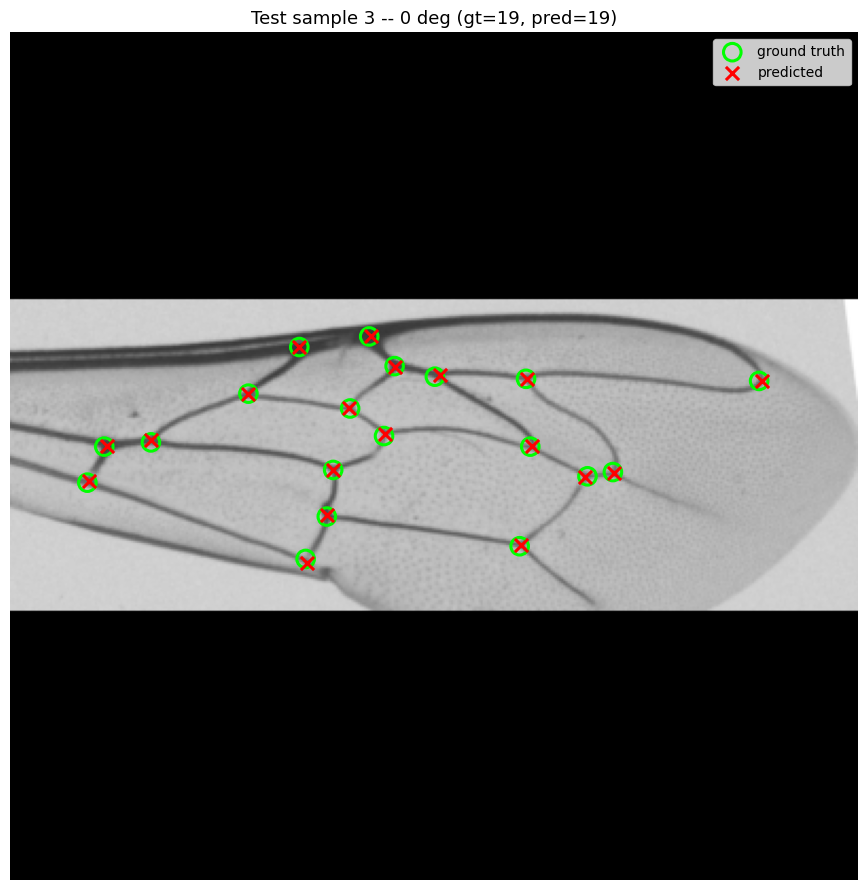

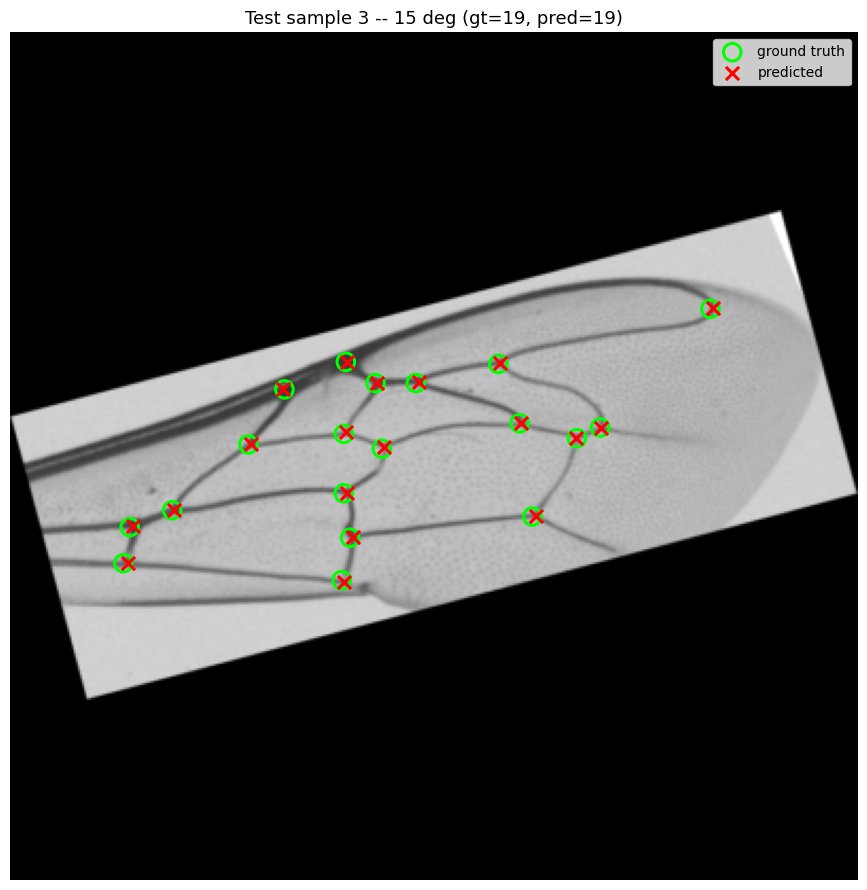

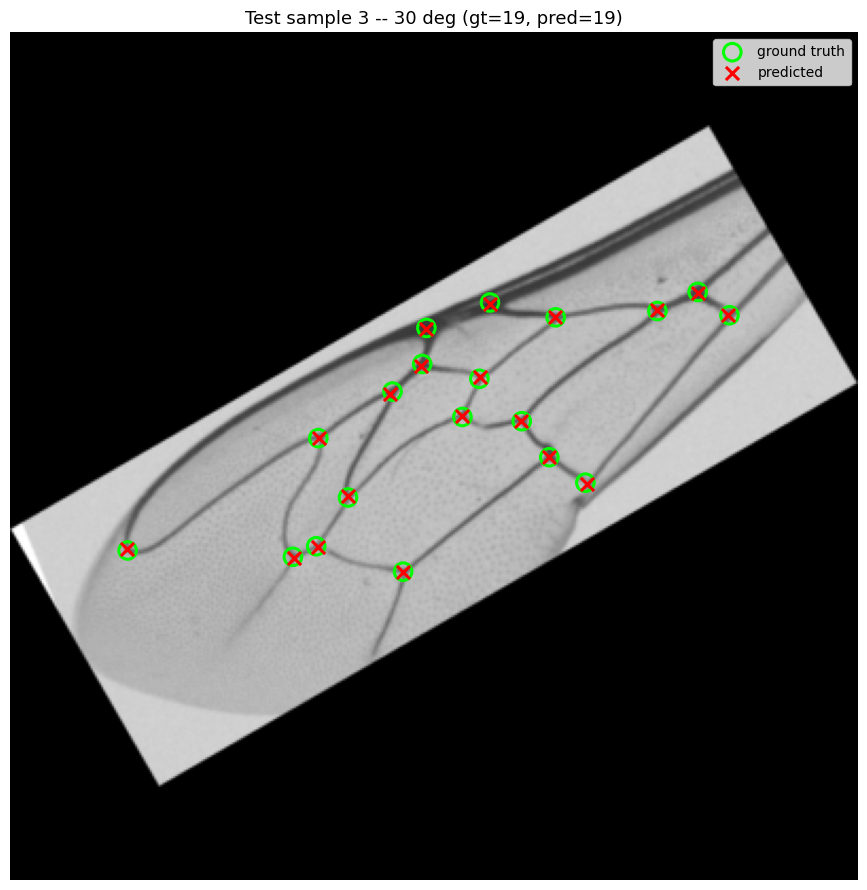

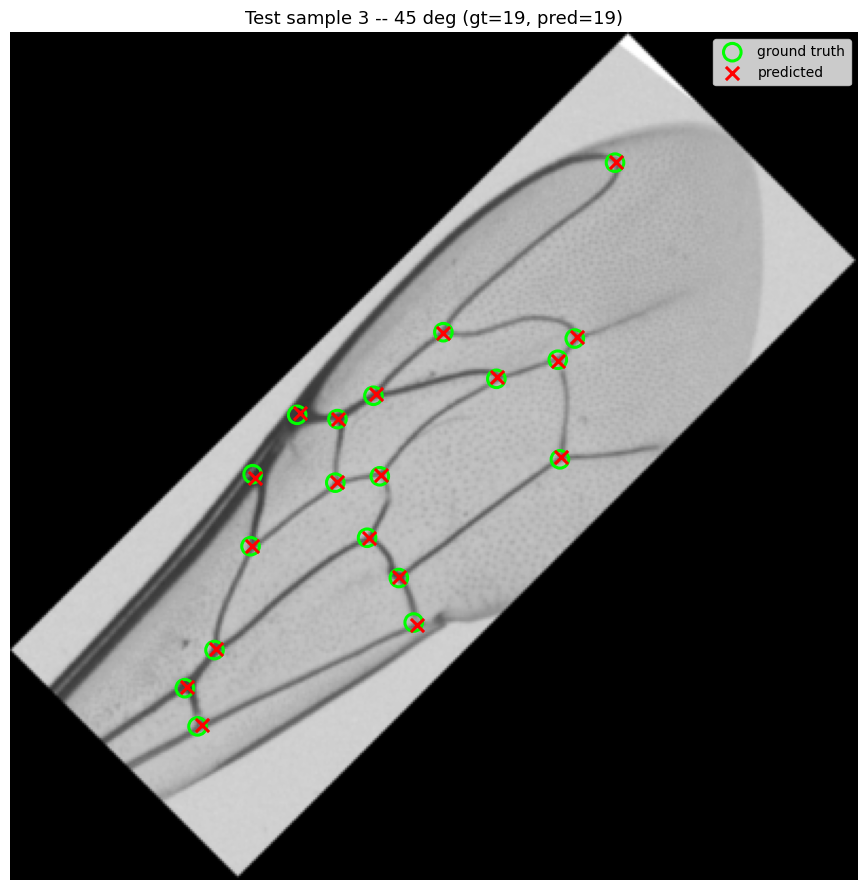

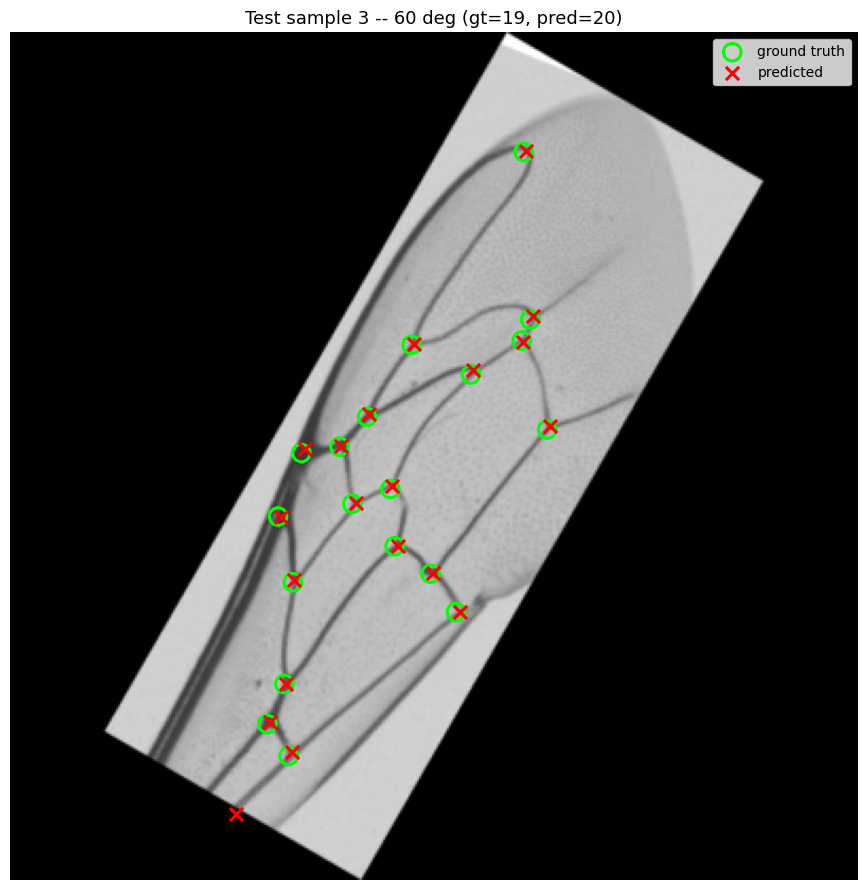

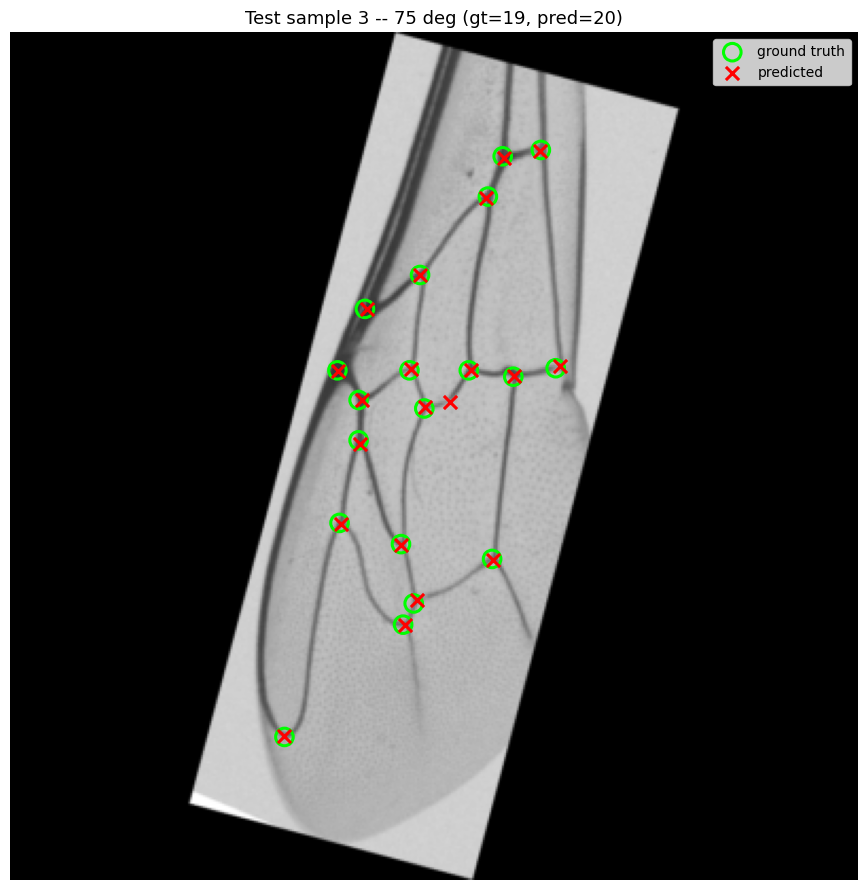

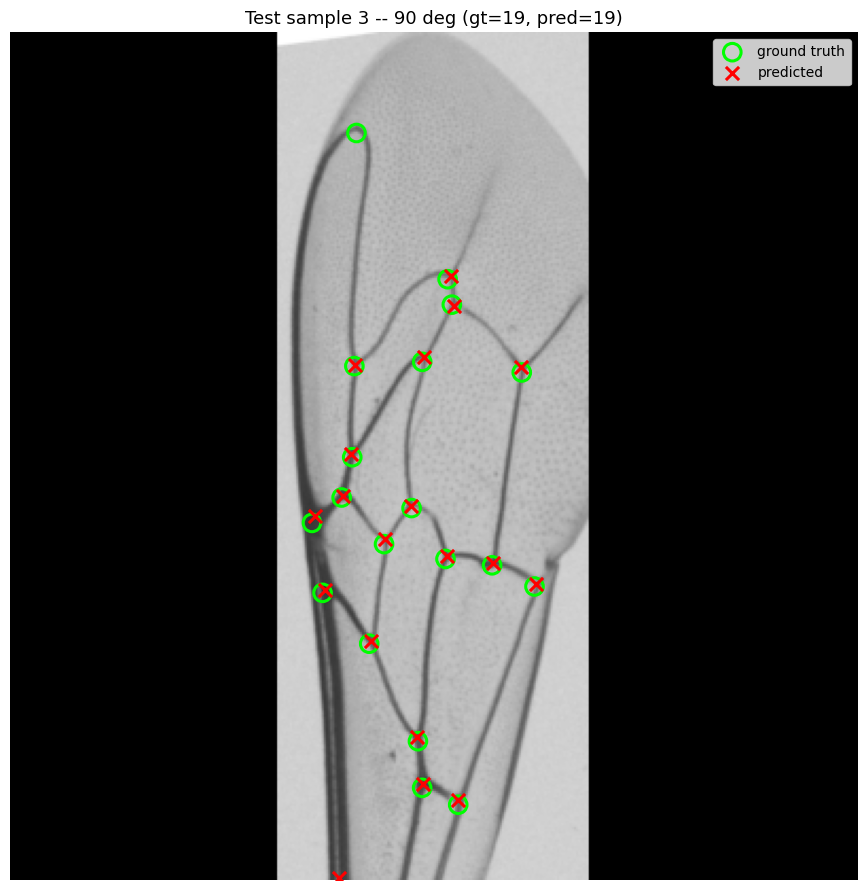

In [4]:
sample_index = 3
angles = [0.0, 15.0, 30.0, 45.0, 60.0, 75.0, 90.0]

for angle in angles:
    cfg = TrainAugmentConfig(rotation_degrees=(angle, angle), triangle_noise_p=0.0, color_jitter_p=0.0)
    image, pred_coords, true_coords = run_sample(sample_index, build_train_transform(OUTPUT_SIZE, cfg))
    show_one(image, pred_coords, true_coords, f"Test sample {sample_index} -- {angle:.0f} deg")

## Section B -- realistic worst case: full config 4 augmentation severity

Same `TrainAugmentConfig` config 4 actually trains on (`jobs/online/README.md`
"Aug B"): rotation +/-90 deg, triangle noise 80% of the time (40-240
triangles), color jitter 100% of the time (0.5-1.5x brightness/contrast).
Each image is an independent random draw -- exactly what the model saw during
training, not a cherry-picked easy case -- shown one after another below.

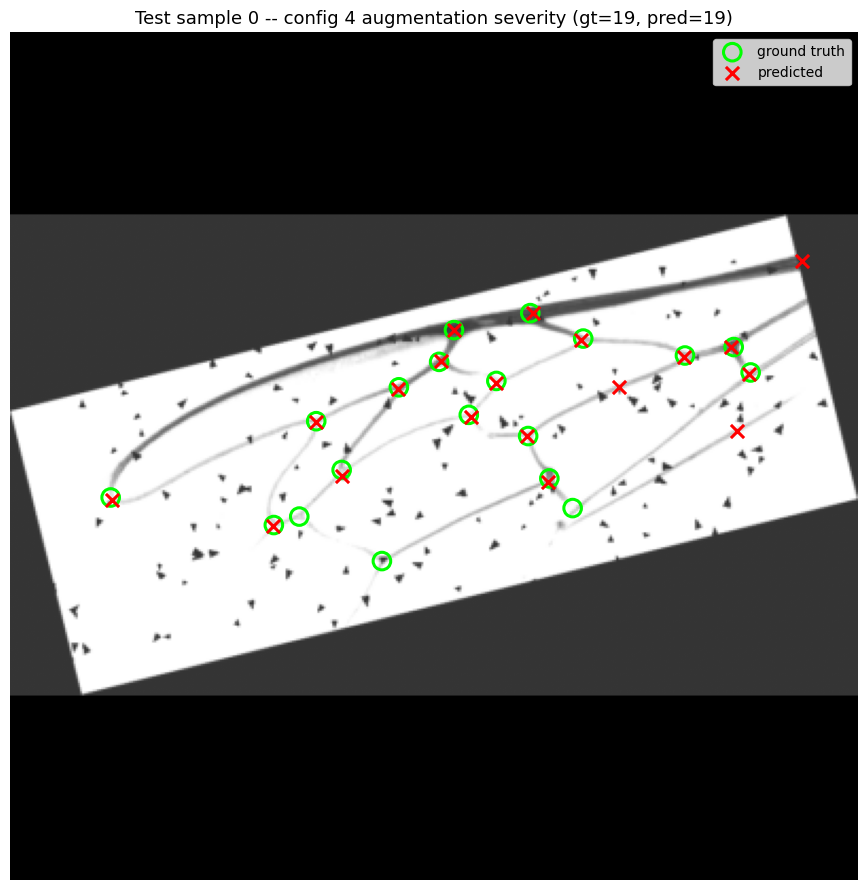

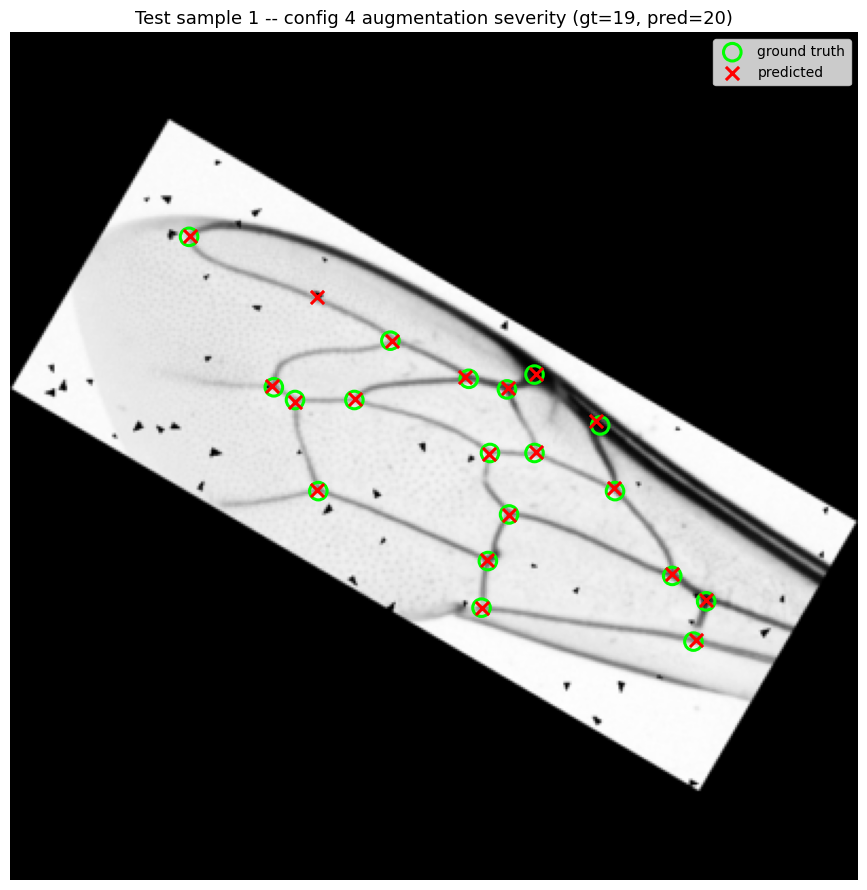

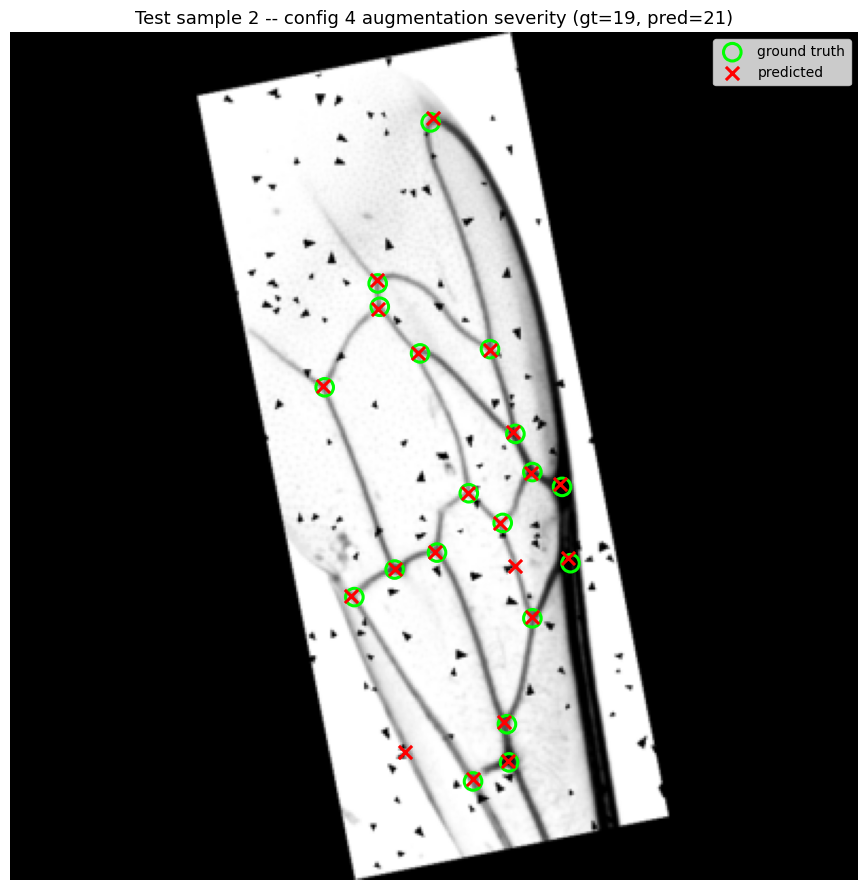

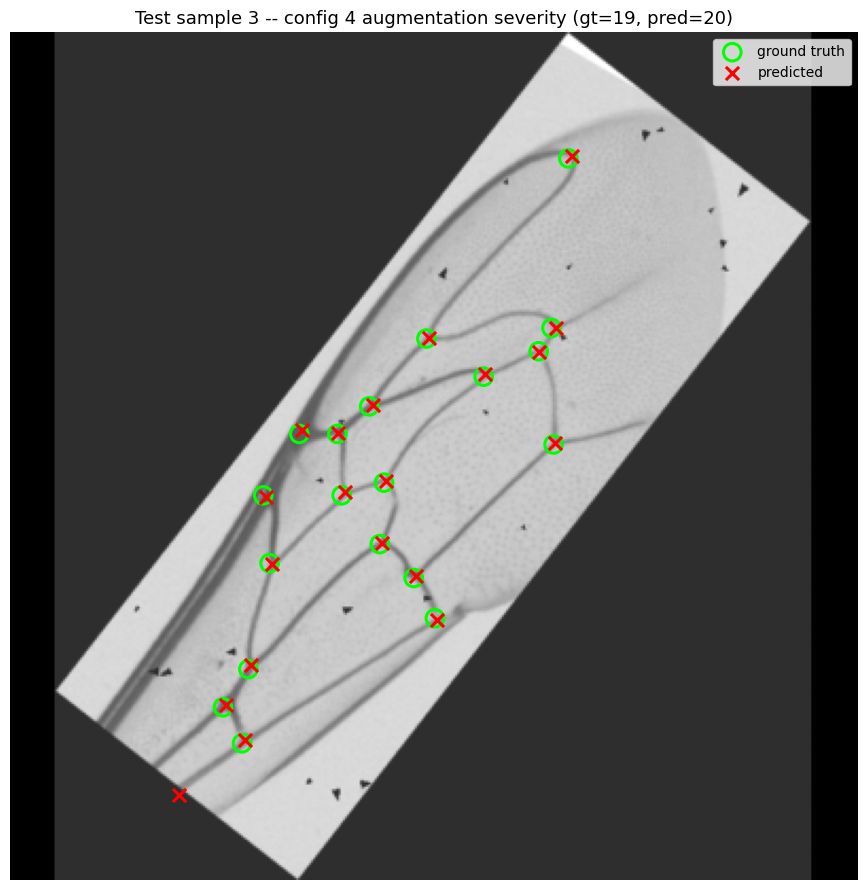

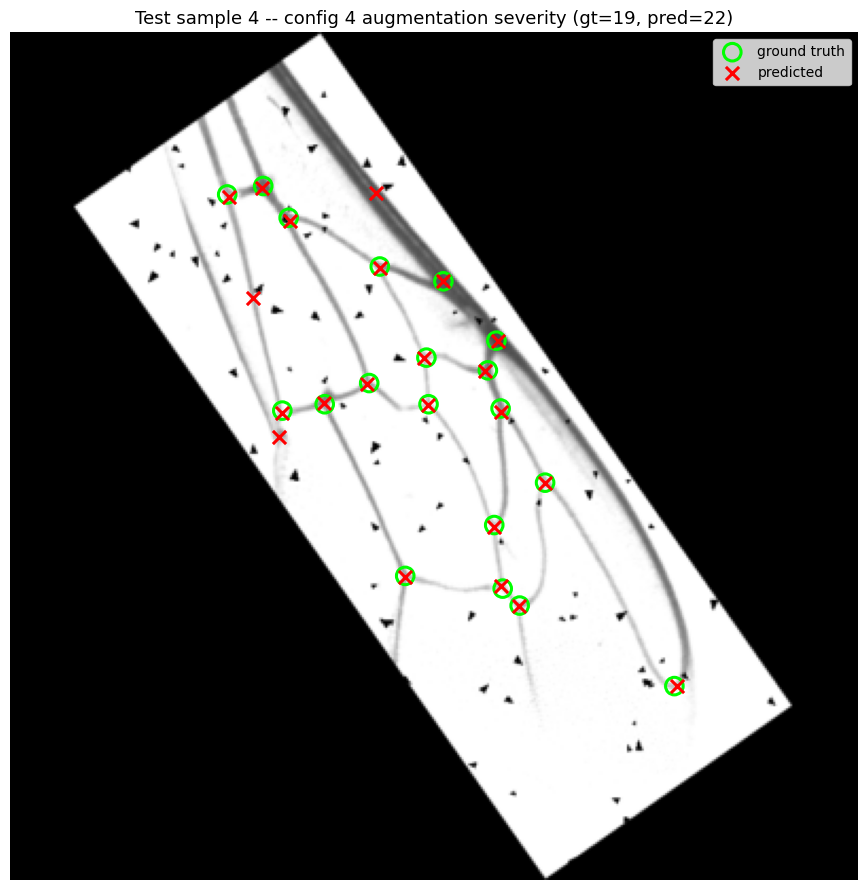

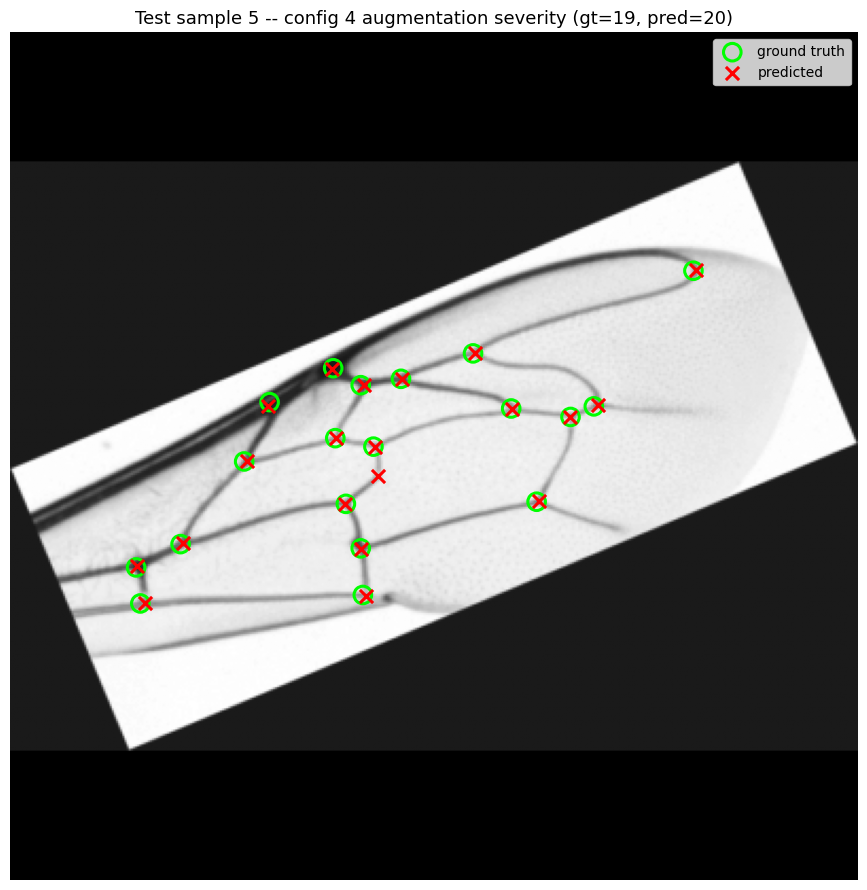

In [5]:
sample_indices = [0, 1, 2, 3, 4, 5]
for idx in sample_indices:
    image, pred_coords, true_coords = run_sample(idx, aug_b_transform)
    show_one(image, pred_coords, true_coords, f"Test sample {idx} -- config 4 augmentation severity")

## Section C -- error vs. rotation angle (quantitative)

Per-sample matched-landmark pixel error, averaged across several test samples
at each fixed rotation angle (no noise/jitter, isolating rotation's effect).
Both **mean** and **median** are tracked deliberately: a handful of genuinely
mismatched points (e.g. a few extra false-positive predictions, or points the
model is truly uncertain about) can pull the mean up a lot while the median
stays low -- a large mean/median gap at some angle means "mostly accurate,
with a few problem points" rather than "uniformly bad," which changes what's
worth investigating (see Section E).

angle=  0.0  mean_error_px=  0.936  median_error_px=  0.732


angle= 15.0  mean_error_px=  0.850  median_error_px=  0.707


angle= 30.0  mean_error_px=  0.967  median_error_px=  0.820


angle= 45.0  mean_error_px=  1.388  median_error_px=  1.034


angle= 60.0  mean_error_px=  1.145  median_error_px=  1.041


angle= 75.0  mean_error_px=  1.202  median_error_px=  1.043


angle= 90.0  mean_error_px=  9.523  median_error_px=  1.581


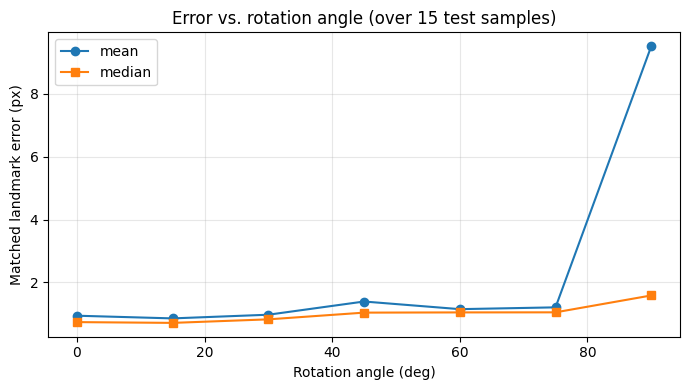

In [6]:
angles = [0.0, 15.0, 30.0, 45.0, 60.0, 75.0, 90.0]
n_samples = 15

mean_errors = []
median_errors = []
for angle in angles:
    cfg = TrainAugmentConfig(rotation_degrees=(angle, angle), triangle_noise_p=0.0, color_jitter_p=0.0)
    transform = build_train_transform(OUTPUT_SIZE, cfg)
    all_distances = []
    for idx in range(n_samples):
        _, pred_coords, true_coords = run_sample(idx, transform)
        d = matched_distances(pred_coords, true_coords)
        if d is not None:
            all_distances.append(d)
    all_distances = torch.cat(all_distances) if all_distances else torch.tensor([])
    mean_errors.append(all_distances.mean().item() if len(all_distances) else float("nan"))
    median_errors.append(all_distances.median().item() if len(all_distances) else float("nan"))
    print(f"angle={angle:>5.1f}  mean_error_px={mean_errors[-1]:7.3f}  median_error_px={median_errors[-1]:7.3f}")

plt.figure(figsize=(7, 4))
plt.plot(angles, mean_errors, marker="o", label="mean")
plt.plot(angles, median_errors, marker="s", label="median")
plt.xlabel("Rotation angle (deg)")
plt.ylabel("Matched landmark error (px)")
plt.title(f"Error vs. rotation angle (over {n_samples} test samples)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section E -- deep dive on one angle

If Section C shows a jump at some particular angle that doesn't look like a
smooth continuation of the surrounding trend, that's worth looking at
directly rather than trusting the average -- a mean over just
`n_samples` can be dominated by one or two hard points rather than reflecting
a genuine, uniform weakness at that angle. Set `DEEP_DIVE_ANGLE` below to
whichever angle looked off in Section C (defaults to 90). Each sample shows
its own mean *and* median matched error plus the predicted/ground-truth
counts -- a sample with mean >> median (and gt != pred) usually means most
points landed fine and a couple of extra/wrong predictions are dragging the
average, not that the model failed on that wing entirely.

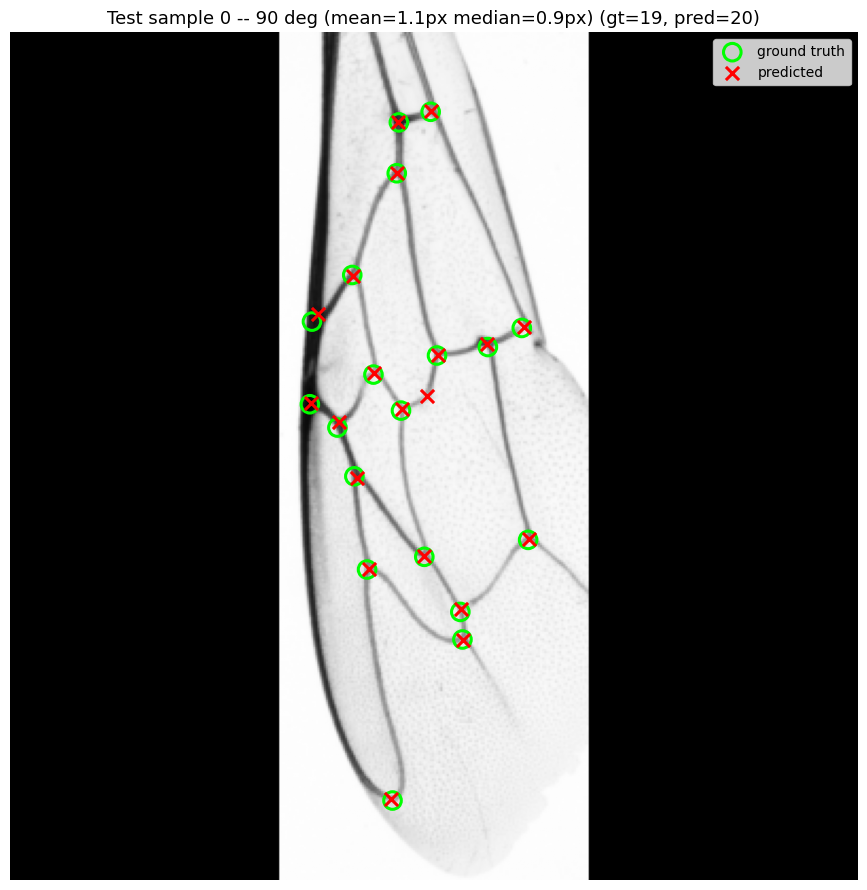

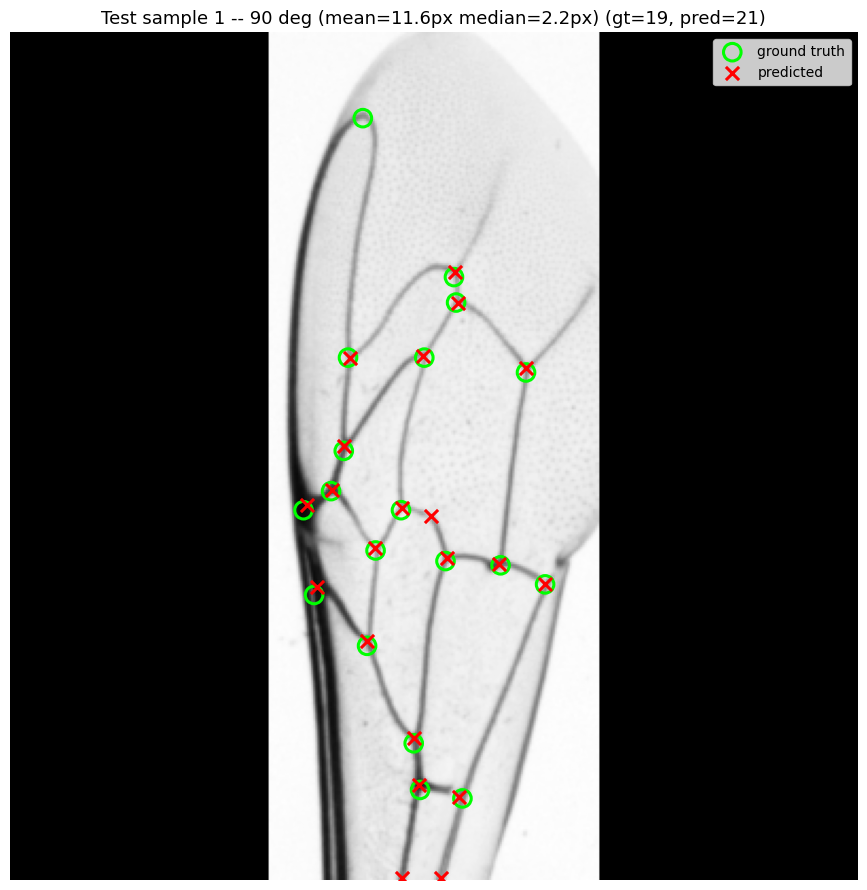

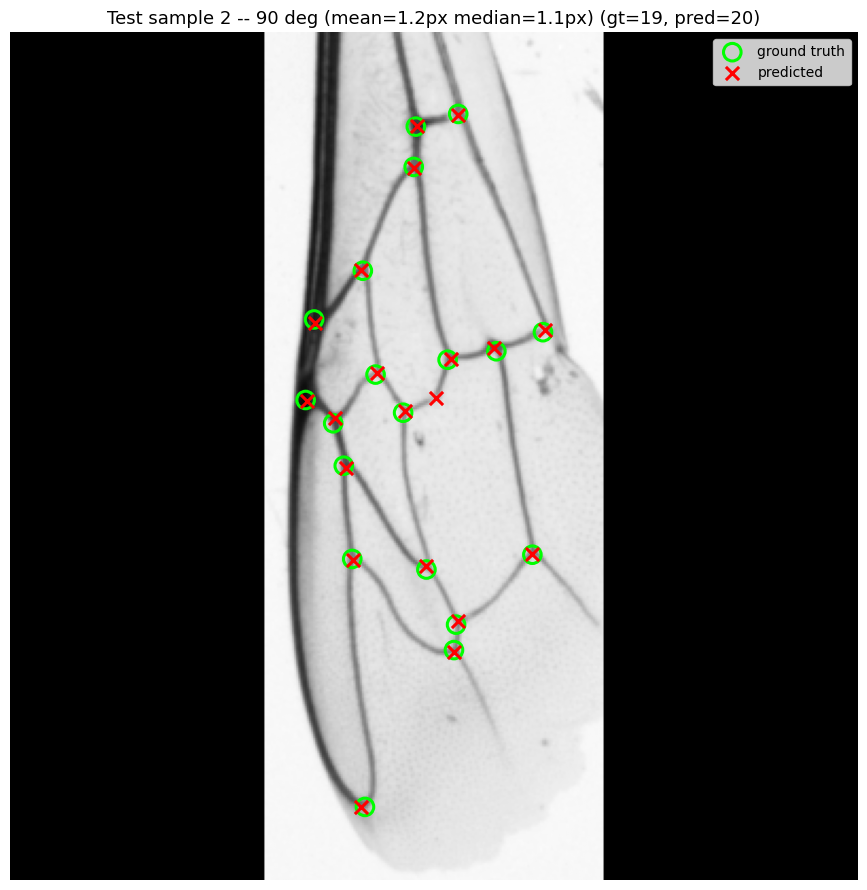

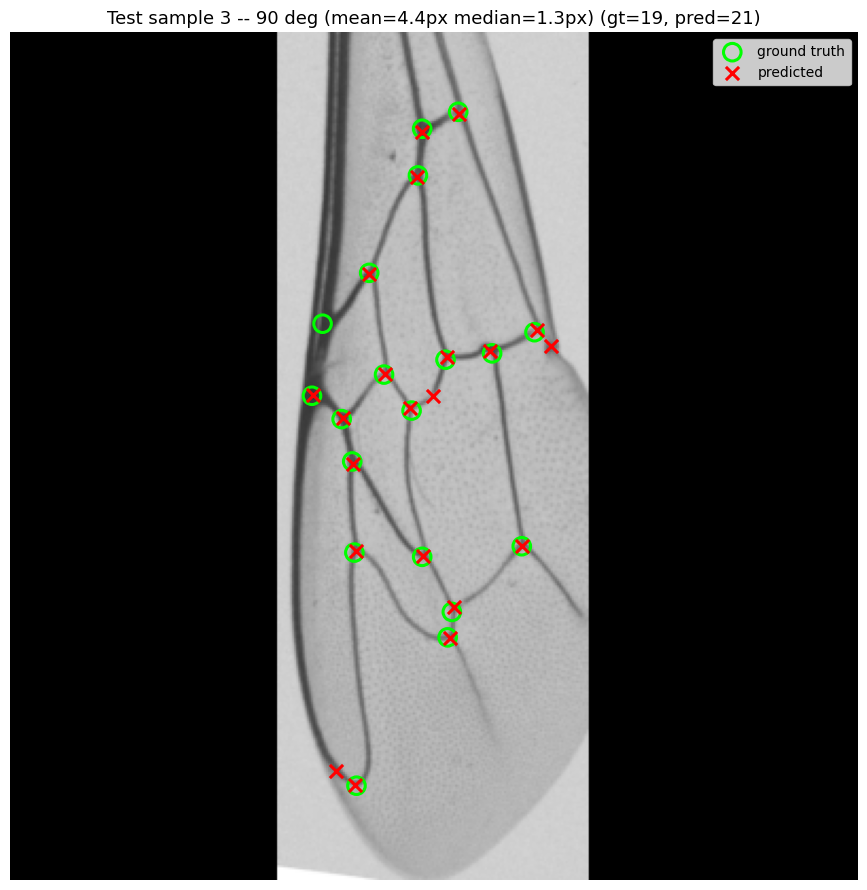

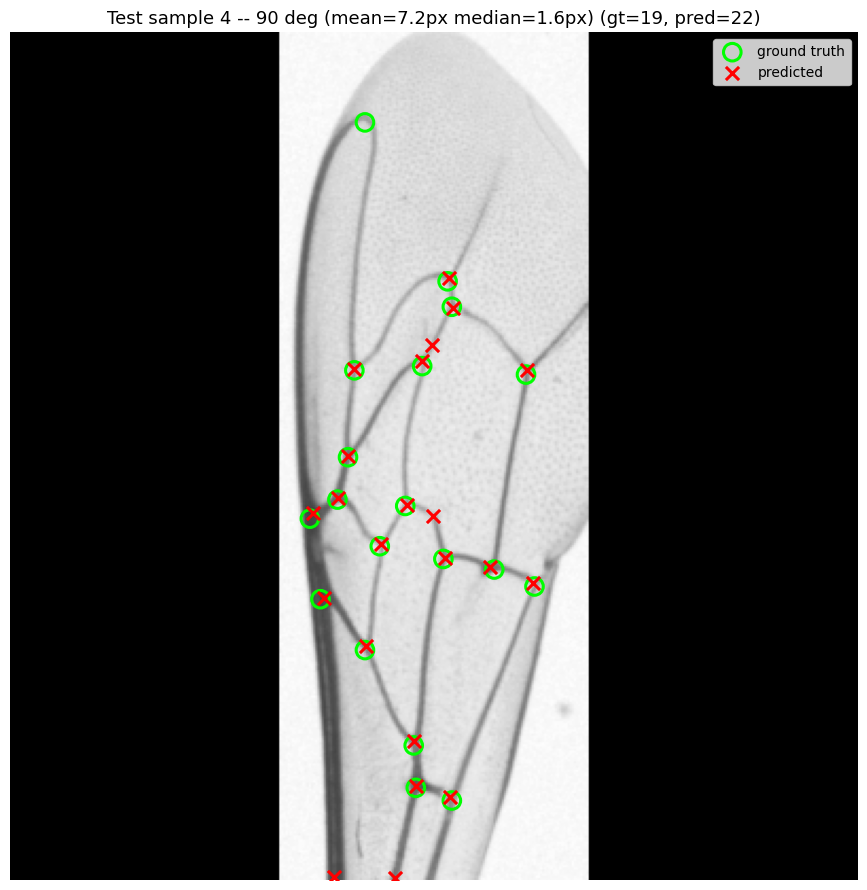

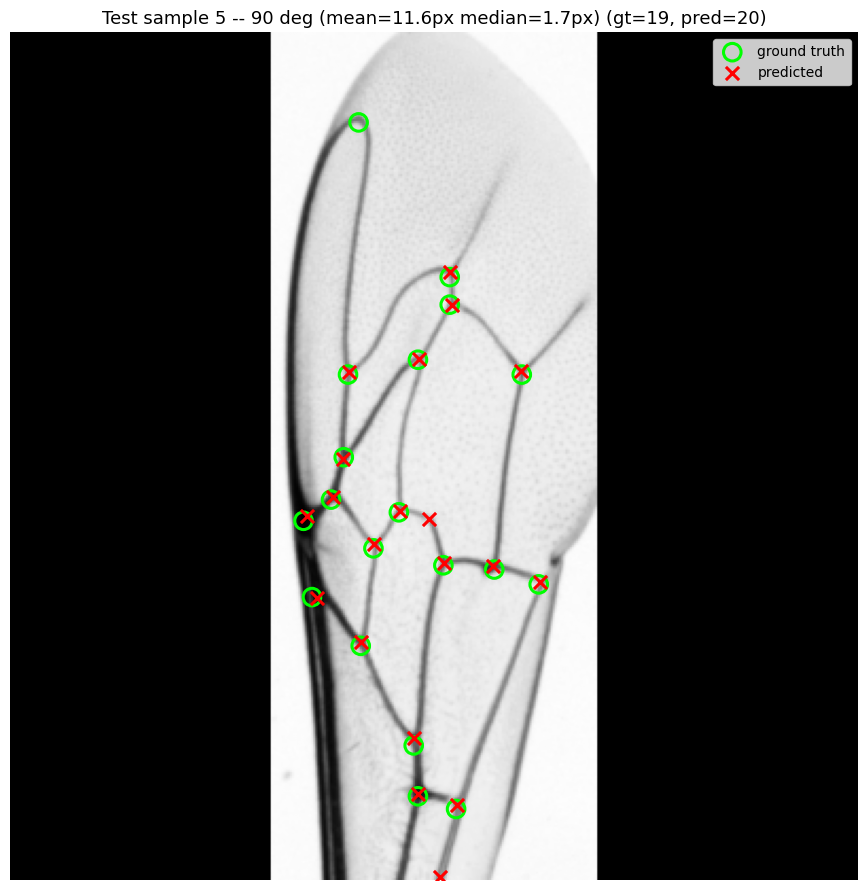

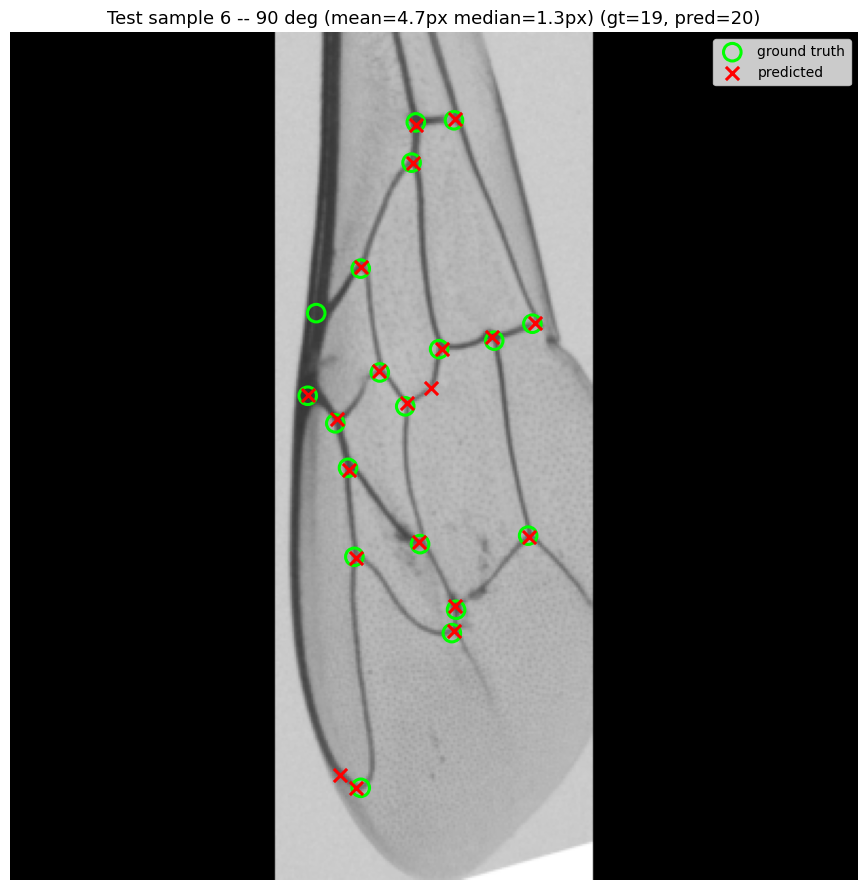

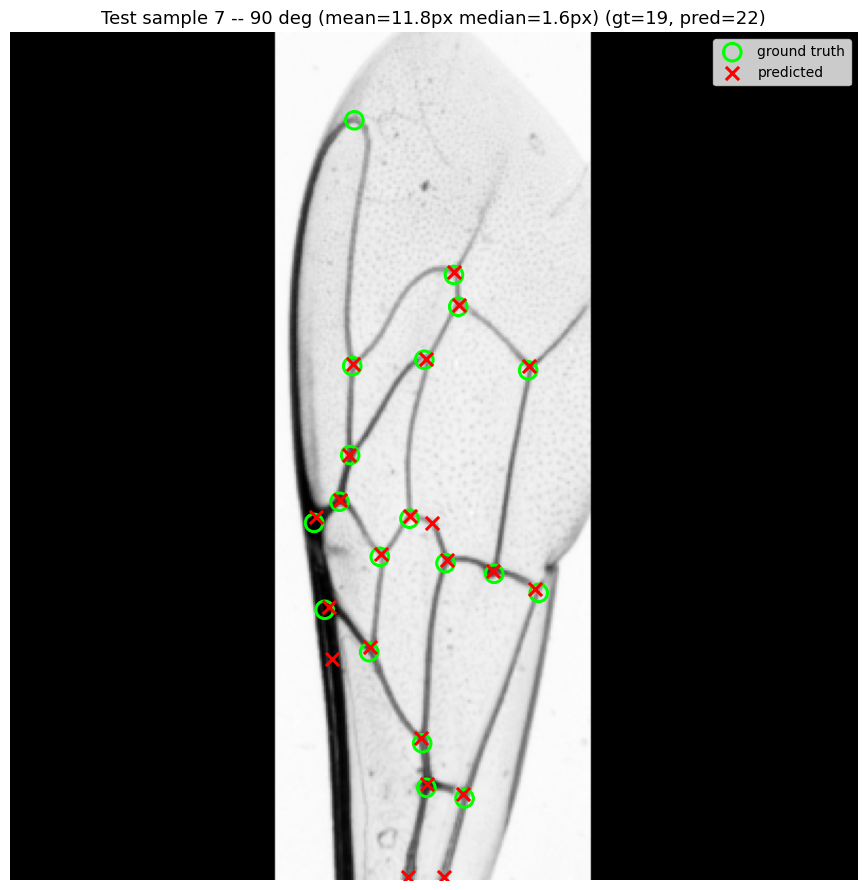

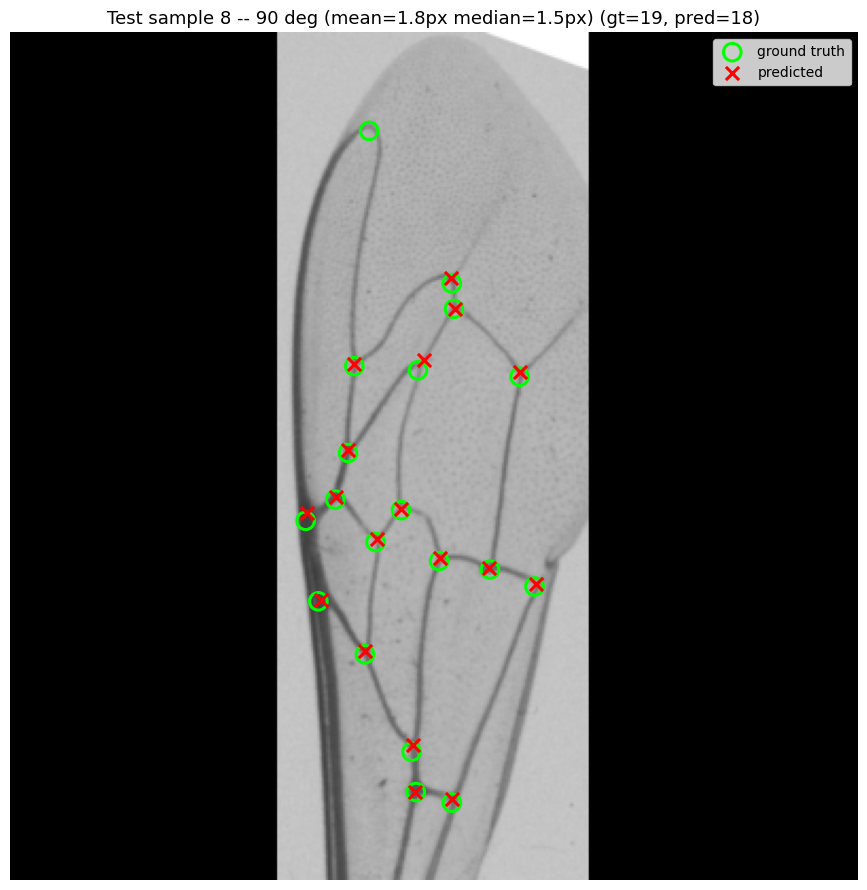

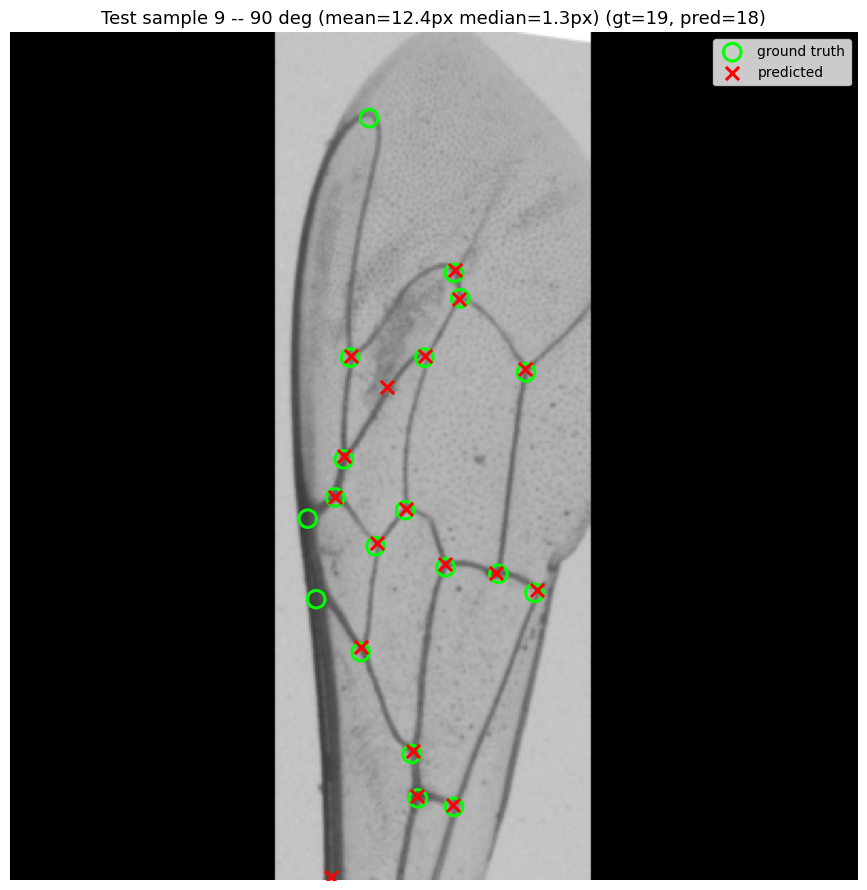

In [7]:
DEEP_DIVE_ANGLE = 90.0
n_deep_dive_samples = 10

deep_dive_cfg = TrainAugmentConfig(rotation_degrees=(DEEP_DIVE_ANGLE, DEEP_DIVE_ANGLE), triangle_noise_p=0.0, color_jitter_p=0.0)
deep_dive_transform = build_train_transform(OUTPUT_SIZE, deep_dive_cfg)

for idx in range(n_deep_dive_samples):
    image, pred_coords, true_coords = run_sample(idx, deep_dive_transform)
    d = matched_distances(pred_coords, true_coords)
    if d is not None:
        err_str = f"mean={d.mean().item():.1f}px median={d.median().item():.1f}px"
    else:
        err_str = "no points detected on one side"
    show_one(image, pred_coords, true_coords, f"Test sample {idx} -- {DEEP_DIVE_ANGLE:.0f} deg ({err_str})")

## Section F -- interactive: re-run for a new random example

**Just re-run this cell** (select it, press Ctrl+Enter / the Run button)
repeatedly -- each execution picks a different random test image and a fresh
random draw of config 4's actual augmentation (new rotation angle, new
triangle noise, new color jitter), runs the model, and shows the overlay. No
setup needed beyond running the cells above once.

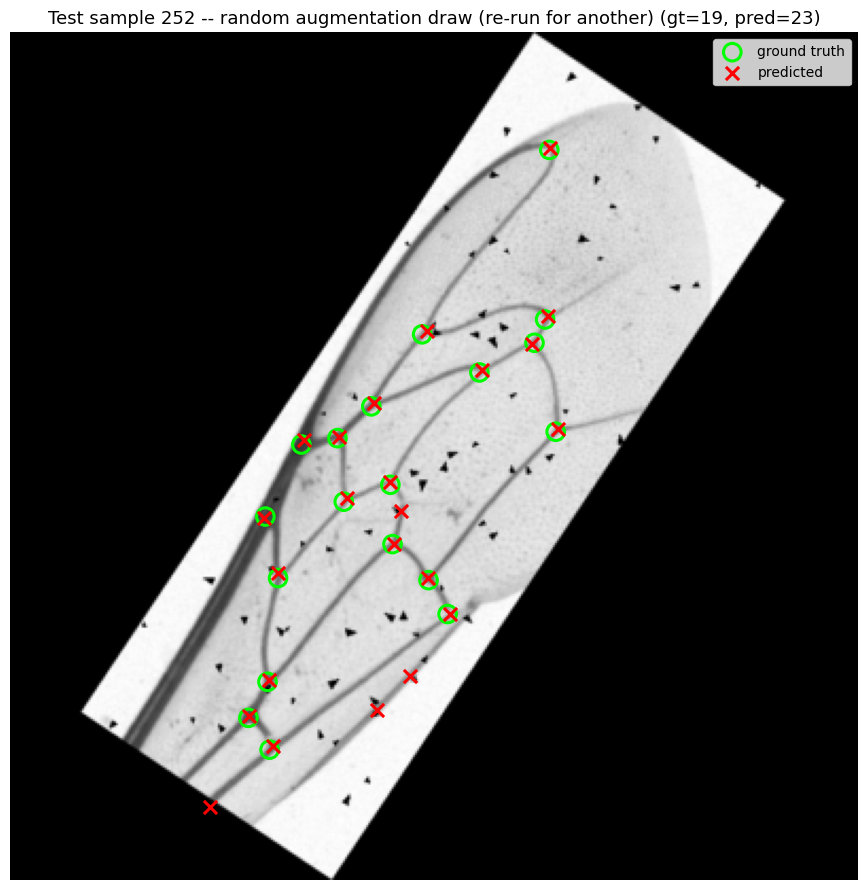

In [8]:
idx = random.randrange(len(test_idx))
image, pred_coords, true_coords = run_sample(idx, aug_b_transform)
show_one(image, pred_coords, true_coords, f"Test sample {idx} -- random augmentation draw (re-run for another)")

## Summary

- Section A shows whether error visibly grows with rotation magnitude for one
  fixed sample -- a rising red-x/green-o gap at 60-90 deg vs. 0 deg would flag
  the model is still weaker on extreme angles despite training on them.
- Section B is the realistic check: this is the actual distribution the model
  trains on, so this is the most representative "how good is it really" view.
- Section C turns that into a number (mean *and* median -- watch for them
  diverging, that's a sign of a few problem points rather than a uniformly
  bad angle): a roughly flat line across angles means rotation robustness is
  genuinely learned; a line that climbs steeply past some angle pinpoints
  where it breaks down.
- Section E digs into any single suspicious angle from Section C sample by
  sample, to tell a genuine per-angle weakness apart from a couple of hard
  points (or extra false-positive predictions) skewing the average.
- Section F is for freely browsing -- keep re-running it to build intuition
  across many random test images/augmentation draws.
- Checking a different/future checkpoint later: update `CHECKPOINT_PATH` in
  the Setup cell (and `MODEL_SIGMOID` if it uses a WeightedDiceLoss-style
  config like 1/3 instead of BCEDiceLoss like 4).